# FlowTrace — EDA on AMLworld HI-Small

**Goal:** understand the dataset completely before building any model.

- What's in it (rows, columns, types)
- How much laundering is there (class balance)
- Time span (for temporal split planning)
- Distributions of amounts, currencies, formats
- Account and bank structure
- Data quality issues
- Pattern file content (which laundering typologies, how many)

In [2]:
# Standard imports and plotting config
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns

# Project root (notebook is in notebooks/, project root is one level up)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Plot style
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13

print("Project root:", PROJECT_ROOT)
print("Data dir:    ", DATA_RAW)
print("Figures dir: ", FIG_DIR)

Project root: c:\Users\Priyam Srivastava\code\flowtrace
Data dir:     c:\Users\Priyam Srivastava\code\flowtrace\data\raw
Figures dir:  c:\Users\Priyam Srivastava\code\flowtrace\reports\figures


In [3]:
# Load HI-Small using our canonical loader
import sys
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from flowtrace.data.schema import load_transactions

df = load_transactions(DATA_RAW / "HI-Small_Trans.csv")
print(f"Loaded {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory: {df.estimated_size('mb'):,.0f} MB in RAM")
print()
print("Schema:")
for name, dtype in df.schema.items():
    print(f"  {name:<22s} {dtype}")

Loaded 5,078,345 rows × 11 columns
Memory: 428 MB in RAM

Schema:
  ts                     Datetime(time_unit='us', time_zone=None)
  from_bank              Int64
  from_account           String
  to_bank                Int64
  to_account             String
  amount_received        Float64
  currency_received      String
  amount_paid            Float64
  currency_paid          String
  payment_format         String
  is_laundering          Int64


## 3. Class balance — how rare is laundering?

The headline number. If 1 in 10 transactions were fraud, this would be a 10-minute project. In reality it's extreme imbalance, and that shapes every downstream choice (metrics, loss function, thresholds).

In [4]:
# Count labels
label_counts = df.group_by("is_laundering").agg(pl.len().alias("count")).sort("is_laundering")
total = df.height

print("Class distribution:")
for row in label_counts.iter_rows(named=True):
    label = "Laundering" if row["is_laundering"] == 1 else "Legitimate"
    pct = 100 * row["count"] / total
    print(f"  {label:<12s}  {row['count']:>10,}  ({pct:.4f}%)")

print(f"\nTotal:         {total:>10,}")

n_pos = label_counts.filter(pl.col("is_laundering") == 1)["count"].item()
n_neg = label_counts.filter(pl.col("is_laundering") == 0)["count"].item()
ratio = n_neg / n_pos
print(f"\nImbalance ratio: 1 laundering : {ratio:,.0f} legitimate")

Class distribution:
  Legitimate     5,073,168  (99.8981%)
  Laundering         5,177  (0.1019%)

Total:          5,078,345

Imbalance ratio: 1 laundering : 980 legitimate


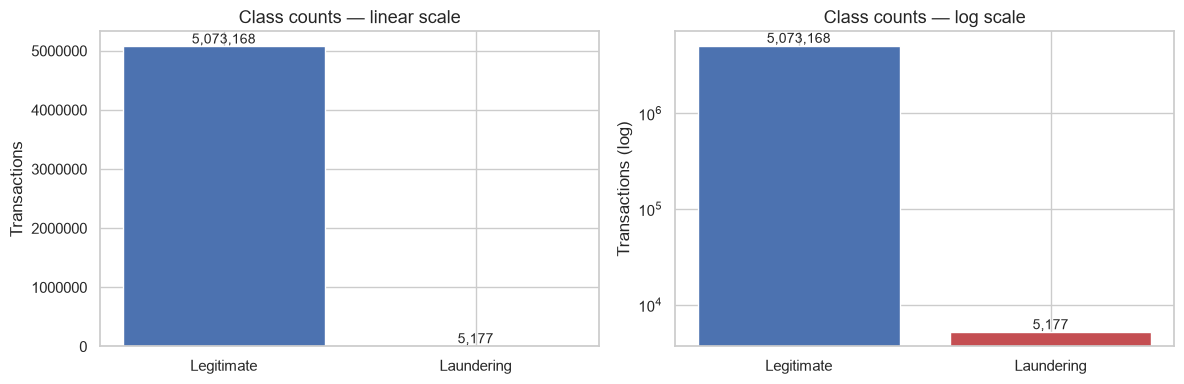

Saved: c:\Users\Priyam Srivastava\code\flowtrace\reports\figures\01_class_balance.png


In [5]:
# Bar chart (not pie — pie charts hide imbalance)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

counts = label_counts.to_pandas().set_index("is_laundering")["count"]
colors = ["#4c72b0", "#c44e52"]

# Left: linear scale (shows how invisible the minority class is)
ax1.bar(["Legitimate", "Laundering"], counts.values, color=colors)
ax1.set_title("Class counts — linear scale")
ax1.set_ylabel("Transactions")
ax1.ticklabel_format(axis="y", style="plain")
for i, v in enumerate(counts.values):
    ax1.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=10)

# Right: log scale (shows actual magnitudes)
ax2.bar(["Legitimate", "Laundering"], counts.values, color=colors)
ax2.set_title("Class counts — log scale")
ax2.set_ylabel("Transactions (log)")
ax2.set_yscale("log")
for i, v in enumerate(counts.values):
    ax2.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig(FIG_DIR / "01_class_balance.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved: {FIG_DIR / '01_class_balance.png'}")

## 4. Time span — temporal structure

For a temporal split we need to know: when does the data start and end, is it continuous, are there daily/hourly patterns, and does laundering rate drift over time?

The split cutoffs we choose here get saved to `configs/split.yaml` and every downstream module respects them.

In [7]:
# Time span
t_min = df["ts"].min()
t_max = df["ts"].max()
span = t_max - t_min

print(f"First transaction: {t_min}")
print(f"Last transaction:  {t_max}")
print(f"Span:              {span}")
print(f"Days:              {span.days}")

# Transactions per day — sort by ts first (polars requirement)
daily = (
    df.sort("ts")
    .group_by_dynamic("ts", every="1d")
    .agg([
        pl.len().alias("total"),
        pl.col("is_laundering").sum().alias("laundering"),
    ])
    .with_columns(
        (pl.col("laundering") / pl.col("total")).alias("laundering_rate")
    )
)

print(f"\nUnique days in data: {daily.height}")
print(f"\nFirst 5 days:")
print(daily.head(5))
print(f"\nLast 5 days:")
print(daily.tail(5))

First transaction: 2022-09-01 00:00:00
Last transaction:  2022-09-18 16:18:00
Span:              17 days, 16:18:00
Days:              17

Unique days in data: 18

First 5 days:
shape: (5, 4)
┌─────────────────────┬─────────┬────────────┬─────────────────┐
│ ts                  ┆ total   ┆ laundering ┆ laundering_rate │
│ ---                 ┆ ---     ┆ ---        ┆ ---             │
│ datetime[μs]        ┆ u32     ┆ i64        ┆ f64             │
╞═════════════════════╪═════════╪════════════╪═════════════════╡
│ 2022-09-01 00:00:00 ┆ 1114921 ┆ 322        ┆ 0.000289        │
│ 2022-09-02 00:00:00 ┆ 754449  ┆ 408        ┆ 0.000541        │
│ 2022-09-03 00:00:00 ┆ 207382  ┆ 391        ┆ 0.001885        │
│ 2022-09-04 00:00:00 ┆ 207430  ┆ 407        ┆ 0.001962        │
│ 2022-09-05 00:00:00 ┆ 482650  ┆ 471        ┆ 0.000976        │
└─────────────────────┴─────────┴────────────┴─────────────────┘

Last 5 days:
shape: (5, 4)
┌─────────────────────┬───────┬────────────┬─────────────────┐
│ t

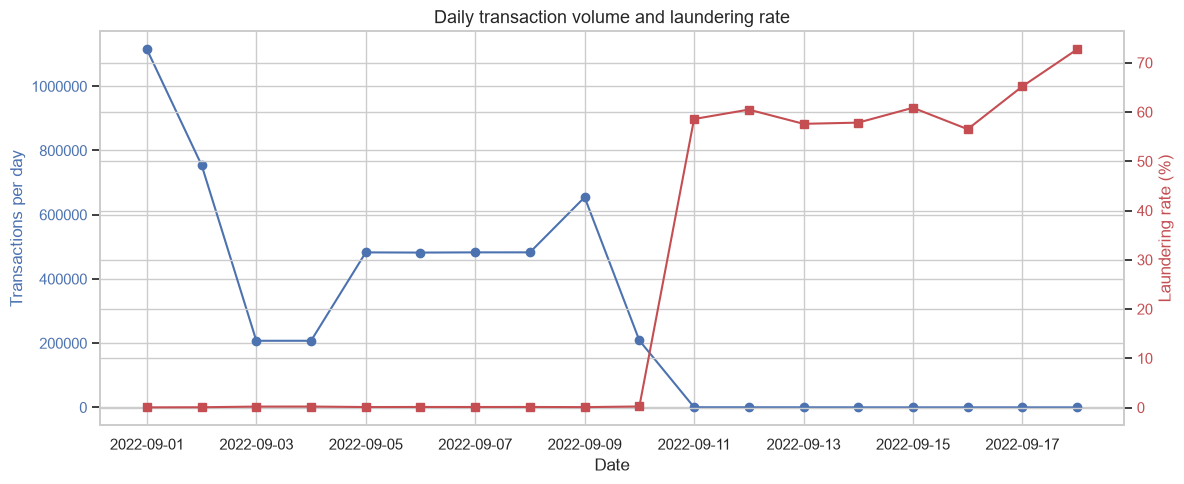

Saved: c:\Users\Priyam Srivastava\code\flowtrace\reports\figures\02_daily_volume.png


In [8]:
# Plot: transactions per day + laundering rate per day on twin axes
fig, ax1 = plt.subplots(figsize=(12, 5))

daily_pd = daily.to_pandas()

color1 = "#4c72b0"
ax1.set_xlabel("Date")
ax1.set_ylabel("Transactions per day", color=color1)
ax1.plot(daily_pd["ts"], daily_pd["total"], marker="o", color=color1, label="Total")
ax1.tick_params(axis="y", labelcolor=color1)
ax1.ticklabel_format(axis="y", style="plain")

ax2 = ax1.twinx()
color2 = "#c44e52"
ax2.set_ylabel("Laundering rate (%)", color=color2)
ax2.plot(daily_pd["ts"], daily_pd["laundering_rate"] * 100, marker="s", color=color2, label="Laundering %")
ax2.tick_params(axis="y", labelcolor=color2)

plt.title("Daily transaction volume and laundering rate")
plt.xticks(rotation=45)
fig.tight_layout()
plt.savefig(FIG_DIR / "02_daily_volume.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved: {FIG_DIR / '02_daily_volume.png'}")

In [9]:
# Full daily table — all 18 rows
print(daily)

shape: (18, 4)
┌─────────────────────┬─────────┬────────────┬─────────────────┐
│ ts                  ┆ total   ┆ laundering ┆ laundering_rate │
│ ---                 ┆ ---     ┆ ---        ┆ ---             │
│ datetime[μs]        ┆ u32     ┆ i64        ┆ f64             │
╞═════════════════════╪═════════╪════════════╪═════════════════╡
│ 2022-09-01 00:00:00 ┆ 1114921 ┆ 322        ┆ 0.000289        │
│ 2022-09-02 00:00:00 ┆ 754449  ┆ 408        ┆ 0.000541        │
│ 2022-09-03 00:00:00 ┆ 207382  ┆ 391        ┆ 0.001885        │
│ 2022-09-04 00:00:00 ┆ 207430  ┆ 407        ┆ 0.001962        │
│ 2022-09-05 00:00:00 ┆ 482650  ┆ 471        ┆ 0.000976        │
│ …                   ┆ …       ┆ …          ┆ …               │
│ 2022-09-14 00:00:00 ┆ 121     ┆ 70         ┆ 0.578512        │
│ 2022-09-15 00:00:00 ┆ 46      ┆ 28         ┆ 0.608696        │
│ 2022-09-16 00:00:00 ┆ 46      ┆ 26         ┆ 0.565217        │
│ 2022-09-17 00:00:00 ┆ 23      ┆ 15         ┆ 0.652174        │
│ 2022-09-

In [10]:
# Where is the volume cliff?
print("\nAll days with their volume:")
print(daily.select(["ts", "total", "laundering", "laundering_rate"]))


All days with their volume:
shape: (18, 4)
┌─────────────────────┬─────────┬────────────┬─────────────────┐
│ ts                  ┆ total   ┆ laundering ┆ laundering_rate │
│ ---                 ┆ ---     ┆ ---        ┆ ---             │
│ datetime[μs]        ┆ u32     ┆ i64        ┆ f64             │
╞═════════════════════╪═════════╪════════════╪═════════════════╡
│ 2022-09-01 00:00:00 ┆ 1114921 ┆ 322        ┆ 0.000289        │
│ 2022-09-02 00:00:00 ┆ 754449  ┆ 408        ┆ 0.000541        │
│ 2022-09-03 00:00:00 ┆ 207382  ┆ 391        ┆ 0.001885        │
│ 2022-09-04 00:00:00 ┆ 207430  ┆ 407        ┆ 0.001962        │
│ 2022-09-05 00:00:00 ┆ 482650  ┆ 471        ┆ 0.000976        │
│ …                   ┆ …       ┆ …          ┆ …               │
│ 2022-09-14 00:00:00 ┆ 121     ┆ 70         ┆ 0.578512        │
│ 2022-09-15 00:00:00 ┆ 46      ┆ 28         ┆ 0.608696        │
│ 2022-09-16 00:00:00 ┆ 46      ┆ 26         ┆ 0.565217        │
│ 2022-09-17 00:00:00 ┆ 23      ┆ 15         ┆

In [11]:
# Force Polars to show all 18 rows (don't truncate)
with pl.Config(tbl_rows=20):
    print(daily)

shape: (18, 4)
┌─────────────────────┬─────────┬────────────┬─────────────────┐
│ ts                  ┆ total   ┆ laundering ┆ laundering_rate │
│ ---                 ┆ ---     ┆ ---        ┆ ---             │
│ datetime[μs]        ┆ u32     ┆ i64        ┆ f64             │
╞═════════════════════╪═════════╪════════════╪═════════════════╡
│ 2022-09-01 00:00:00 ┆ 1114921 ┆ 322        ┆ 0.000289        │
│ 2022-09-02 00:00:00 ┆ 754449  ┆ 408        ┆ 0.000541        │
│ 2022-09-03 00:00:00 ┆ 207382  ┆ 391        ┆ 0.001885        │
│ 2022-09-04 00:00:00 ┆ 207430  ┆ 407        ┆ 0.001962        │
│ 2022-09-05 00:00:00 ┆ 482650  ┆ 471        ┆ 0.000976        │
│ 2022-09-06 00:00:00 ┆ 482089  ┆ 531        ┆ 0.001101        │
│ 2022-09-07 00:00:00 ┆ 482751  ┆ 497        ┆ 0.00103         │
│ 2022-09-08 00:00:00 ┆ 482773  ┆ 539        ┆ 0.001116        │
│ 2022-09-09 00:00:00 ┆ 654467  ┆ 514        ┆ 0.000785        │
│ 2022-09-10 00:00:00 ┆ 208325  ┆ 442        ┆ 0.002122        │
│ 2022-09-